In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


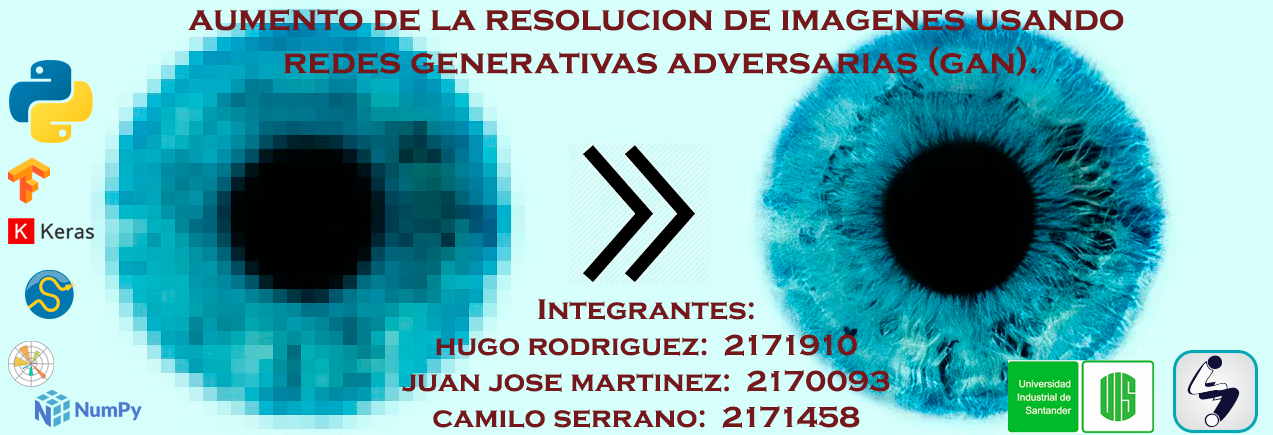

# Librerias usadas#

In [1]:
#Librerias
import keras
import numpy as np
import tensorflow as tf
from os.path import join, isfile
import scipy.io as sio
from tensorflow.keras.utils import Sequence
import os
from matplotlib import pyplot as plt
from os import listdir
from tensorflow.keras import regularizers
from scipy.io import loadmat
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.python.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from keras import backend as Kt
from tensorflow.keras.callbacks import ModelCheckpoint

##DATASET##
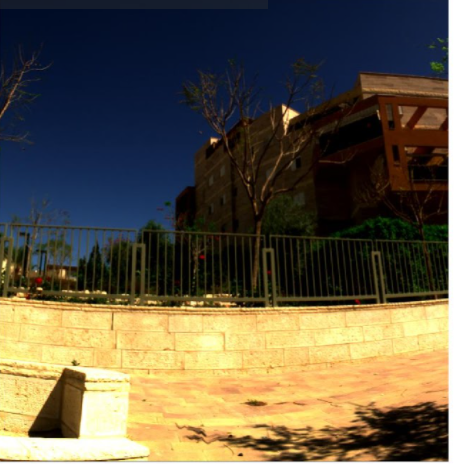

Para la creacion del dataset Utilizamos imagenes en formato .mat con resoluciones de 1392×1300×31  200u, de la pagina http://icvl.cs.bgu.ac.il/hyperspectral/.

Posterior a esto hicimos una segmentacion de la imagen para convertirla a dimensiones de 256×256×12. y dividimos el dataseth en 2. Imagenes de alta, e imagenes de baja calidad. las cuales ser redimenzionaron a la resolucion de 64×64×12 y se le aplico un filtro gaussiano para tener una imagen distorsionada.

Proceso:


1.

   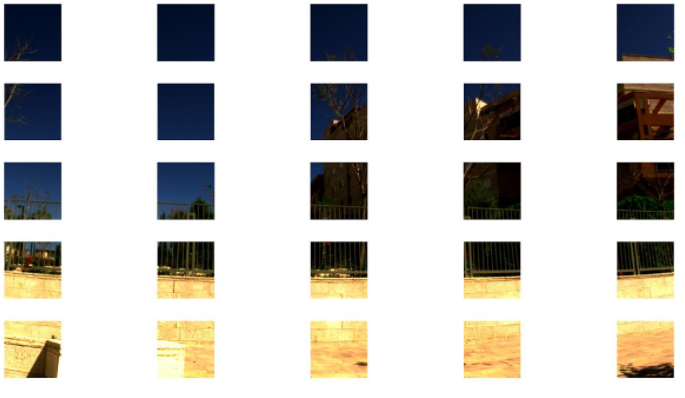 
2.   

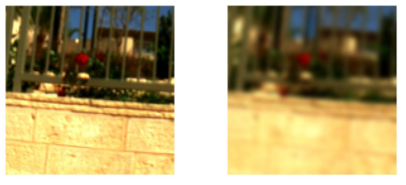


3.  

    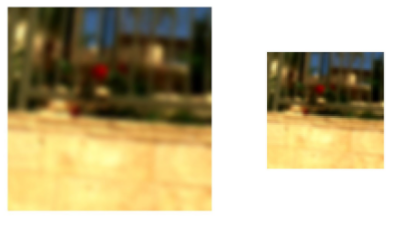





###RESULTADO

Obtuvimos un Dataset de imagenes de 4390.

#Generador(Arquitectura U-NET)
La U-net es una arquitectura de red convolucional para una segmentación de imágenes rápida y precisa.

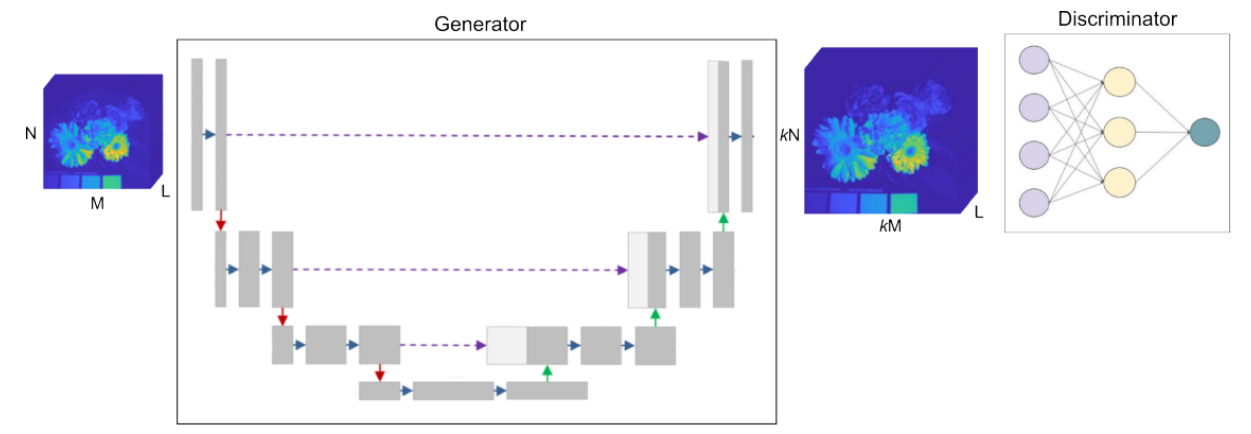

In [2]:
## Modelo del Generador
#Arquitectura U-NET
def generator(pretrained_weights=None, input_size=(64, 64, 12), depth=12):
#definimos la entrada del modelo
    inputs = Input(shape=input_size)
#Codificador
    conv1 = Conv2D(16, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                   dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(inputs)
    conv1 = Dropout(0.1)(conv1)
    conv11 = MaxPooling2D(pool_size=(2, 2))(conv1)
    
    conv12 = Conv2D(32, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                    dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv11)
    conv12 = Dropout(0.1)(conv12)
    conv15 = MaxPooling2D(pool_size=(2, 2))(conv12)
    
    conv150 = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                    dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv15)
    conv150 = Dropout(0.2)(conv150)
    conv16 = MaxPooling2D(pool_size=(2, 2))(conv150)

    conv17 = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                    dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv16)
    conv17 = Dropout(0.1)(conv17)
    conv18 = MaxPooling2D(pool_size=(2, 2))(conv17)

    conv19 = Conv2D(256, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                    dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv18)
    conv19 = Dropout(0.1)(conv19)

#Decodificador
    conv13 = UpSampling2D(size=(2, 2))(conv19)
    conv1317 = Concatenate()([conv13, conv17])
    conv151 = Conv2D(128, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                     dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv1317)
    conv151 = Dropout(0.2)(conv151)                 
    conv250 = UpSampling2D(size=(2, 2))(conv151)
    conv1250 = Concatenate()([conv250, conv150])
    conv251 = Conv2D(64, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                     dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv1250)
    conv251 = Dropout(0.1)(conv251)
    conv252 = UpSampling2D(size=(2, 2))(conv251)
    conv1252 = Concatenate()([conv252, conv12])
    conv253 = Conv2D(32, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                     dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv1252)
    conv253 = Dropout(0.1)(conv253)
    conv254 = UpSampling2D(size=(2, 2))(conv253)
    conv1254 = Concatenate()([conv254, conv1])
    conv255 = Conv2D(16, (3, 3), padding="same", kernel_initializer='he_normal', activation="relu",
                     dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001))(conv1254)
    conv255 = Dropout(0.1)(conv255)
    conv7 = Conv2D(12, (1, 1), padding="same", kernel_initializer='he_normal', activation="relu",
                     dilation_rate=(2, 2), kernel_regularizer = regularizers.l2(0.001), name='output_f1')(conv255)
    model = Model(inputs, conv7)
    if (pretrained_weights):
      model.load_weights(pretrained_weights)
    return model

#Discriminador(Arquitectura PatchGAN)#
El discriminador tiene como tarea medir la similitud de la imagen de entrada con una imagen desconocida . Esta imagen desconocida pertenece al conjunto de datos
La arquitectura de la PatchGAN consiste en quecada píxel de la salida del discriminador corresponde al parche de N × N de la imagen de entrada.



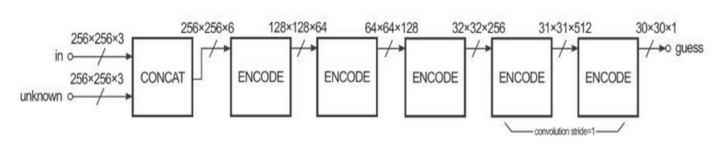

In [3]:
def downsample(filters, size, apply_batchnorm=True):
  initializer = tf.random_normal_initializer(0., 0.02)
  
  result = tf.keras.Sequential()
  result.add(
      tf.keras.layers.Conv2D(filters, size, strides=2, padding='same',
                             kernel_initializer=initializer, use_bias=False))

  if apply_batchnorm:
    result.add(tf.keras.layers.BatchNormalization())

  result.add(tf.keras.layers.LeakyReLU())

  return result

In [4]:
# Discriminador
def Discriminator():
  initializer = tf.random_normal_initializer(0., 0.02)
#Imagen real
  inp = tf.keras.layers.Input(shape=[256, 256, 12], name='input_image')
#Imagen Reconstruida
  tar = tf.keras.layers.Input(shape=[256, 256, 12], name='target_image')

  x = tf.keras.layers.concatenate([inp, tar])

  down1 = downsample(64, 4, False)(x) 
  down2 = downsample(128, 4)(down1) 
  down3 = downsample(256, 4)(down2) 

  zero_pad1 = tf.keras.layers.ZeroPadding2D()(down3) 
  conv = tf.keras.layers.Conv2D(512, 4, strides=1,
                                kernel_initializer=initializer,
                                use_bias=False)(zero_pad1) 

  batchnorm1 = tf.keras.layers.BatchNormalization()(conv)

  leaky_relu = tf.keras.layers.LeakyReLU()(batchnorm1)

  zero_pad2 = tf.keras.layers.ZeroPadding2D()(leaky_relu) 

  last = tf.keras.layers.Conv2D(1, 4, strides=1,
                                kernel_initializer=initializer)(zero_pad2) 

  return tf.keras.Model(inputs=[inp, tar], outputs=last)
discriminator = Discriminator()
print(discriminator)

In [5]:
# Funciones de perdida

cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def custom_loss():
  def lossimage(y_true, y_pred):
    val = tf.reduce_mean(tf.norm(y_pred - y_true, ord='fro', axis=(1, 2)))
    return val
  return lossimage

def PSNR(y_true, y_pred):# Y imagen De alta y G salida del generador

  dim = y_true.shape
  temp = tf.divide(1.0, tf.multiply(tf.pow(tf.norm(y_pred - y_true, ord='fro', axis=(1, 2)),2),1/(dim[1]*dim[2])))
  psnr = tf.multiply(tf.pow(tf.reduce_max(y_pred, axis=(1, 2)),2),temp)
  psnr = 10.0*tf.math.log(psnr) / tf.math.log(10.0)
  return tf.reduce_mean(psnr, axis=-1)

In [6]:
# Entrenamiento de la GAN

callback_path_gen = "/content/drive/My Drive/Loss/cp-{epoch:04d}.ckpt"
callback_dir_gen = os.path.dirname(callback_path_gen)
latest_gen = tf.train.latest_checkpoint(callback_dir_gen)

generator_optimizer = tf.keras.optimizers.Adam(1e-3, amsgrad=False)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-3, beta_1=0.5)
G = generator(pretrained_weights=latest_gen, input_size=(256, 256, 12), depth=12)

lossimage = custom_loss()

@tf.function
def train_step(images):  
  print("Paso1")
  with tf.GradientTape() as G1_tape, tf.GradientTape() as G2_tape:
    generated_images = G(tf.cast(images[0], dtype=tf.float32), training=True)
    gen_loss = lossimage(tf.cast(images[0], dtype=tf.float32), generated_images)
    gen_loss_im = gen_loss
    gen_loss = gen_loss + tf.math.reduce_sum(G.losses)
    disc_real_output = discriminator([images[0], images[0]], training=True)
    disc_generated_output = discriminator([images[0], generated_images], training=True)
    disc_loss = discriminator_loss(disc_real_output, disc_generated_output) 
  gradients_of_G1 = G1_tape.gradient(gen_loss, G.trainable_weights)
  discriminator_gradients = G2_tape.gradient(disc_loss, discriminator.trainable_weights)

  generator_optimizer.apply_gradients(zip(gradients_of_G1, G.trainable_weights))
  discriminator_optimizer.apply_gradients(zip(discriminator_gradients, discriminator.trainable_weights))
  return gen_loss_im, gen_loss

In [7]:
#Procesamiento de datos


class DataGenerator(Sequence):

    def __init__(self, list_IDs, flag_tr, D, im_path,im_path2, dic_img,dic_img2, batch_size=10, dim2=(64, 64, 12), dim=(256, 256, 12), shuffle=True, augment=False):

        # Inicializa parametros
        self.im_path2 = im_path2
        self.dim2 = dim2
        self.dim = dim
        self.batch_size = batch_size
        self.list_IDs = list_IDs
        self.flag_tr = flag_tr
        self.D = D
        self.im_path = im_path
        self.dic_img = dic_img
        self.dic_img2 = dic_img2
        self.shuffle = shuffle
        self.augment = augment
        self.on_epoch_end()

    def __len__(self):
        # Numero de batches por epoca
        return int(np.floor(len(self.list_IDs) / self.batch_size))

    def __getitem__(self, index):
        #Generacion de un batch de data
        # Genera los indices
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Encuentra la lista de IDs
        list_IDs_temp = [self.list_IDs[k] for k in indexes]

        # Genera los datos
        if flag_tr:
          X, Y, W = self.__data_generation(list_IDs_temp)
          return X, Y, W
        else:
          X, Y = self.__data_generation(list_IDs_temp)
          return X, Y       

    def on_epoch_end(self):
        # Actualiza los indices depues de cada epoca
        self.indexes = np.arange(len(self.list_IDs))
        if self.shuffle == True:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_IDs_temp):
        X = np.empty([self.batch_size, *self.dim])
        Y = np.empty([self.batch_size, *self.dim2])
        W = np.empty([self.batch_size])

        # Generador de datos
        for i, ID in enumerate(list_IDs_temp):
            img_X = sio.loadmat(join(self.im_path, ID))[self.dic_img]
            img_Y = sio.loadmat(join(self.im_path2, ID))[self.dic_img2]
            img_X = img_X/np.max(tf.reshape(img_X,-1))
            img_Y = img_Y/np.max(tf.reshape(img_Y,-1))

            if self.augment:
                transform_params = self.D.get_random_transform(self.dim)
                img_X = self.D.apply_transform(x=np.array(img_X), transform_parameters=transform_params)
            
            X[i,] = img_X
            Y[i,] = img_Y
        if flag_tr:
          return X, Y, W
        else:
          return X, Y

In [ ]:
## Run
# Entrenamiento
# Parametros
BATCH_SIZE = 10; EPOCHS=50; IMG_WIDTH = 256; IMG_HEIGHT = 256; L_bands = 12; 

# Dataseth
dataset_path = '/content/drive/My Drive/High quality image training'
dataset_path_2 = '/content/drive/My Drive/Low quality image training'

dataset_dict = 'HI'
dataset_dict_2 = 'LI'

#---------------------Generador-----------------------------------------------------------------------------------------

D = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)

params = {'dim': (IMG_WIDTH, IMG_HEIGHT, L_bands),
          'dim2': (64, 64, 12),
          'batch_size': BATCH_SIZE,
          'im_path': dataset_path,
          'im_path2':dataset_path_2,
          'dic_img': dataset_dict,
          'dic_img2': dataset_dict_2,
          'shuffle': True,
          'augment': False} 

# rutas a las imágenes
HyperFiles = [
        fn 
        for fn in listdir(dataset_path)
        if isfile(join(dataset_path, fn))
           and fn.lower().endswith(('.mat'))
    ]

HyperFiles = HyperFiles[:500]
print('Training images: ',len(HyperFiles))

flag_tr=False
train_gen = DataGenerator(HyperFiles, flag_tr, D, **params)

#----------------Corremos la red--------------------------------------------------------------------------------------------

num_batch = train_gen.__len__()
train_loss_results = []

for i in range(EPOCHS):
  train_gen.on_epoch_end()
  loss_avg_gen_im = tf.keras.metrics.Mean()
  loss_avg_gen = tf.keras.metrics.Mean()
 


  for j in range(num_batch):
    x, y = train_gen.__getitem__(j)
    
    gen_loss_im, gen_loss = train_step([x,y])#Probar funcionamiento X,Y ó [X,Y]
    loss_avg_gen_im.update_state(gen_loss_im)
    loss_avg_gen.update_state(gen_loss)

  print("Epoch {:04d}: Loss GEN_total: {:.3f}: Loss Image: {:.6f}: Loss Aperture: {:.6f}".format(i, loss_avg_gen.result(), loss_avg_gen_im.result(), tf.math.reduce_sum(G.losses).numpy()))
  if (i+1) % 30 == 0:
    G.save_weights(callback_path_gen.format(epoch=0), overwrite=True)


Training images:  500
Epoch 0000: Loss GEN_total: 6.504: Loss Image: 6.441715: Loss Aperture: 0.062527
Epoch 0001: Loss GEN_total: 6.455: Loss Image: 6.393149: Loss Aperture: 0.062124
Epoch 0002: Loss GEN_total: 6.439: Loss Image: 6.377006: Loss Aperture: 0.061878
Epoch 0003: Loss GEN_total: 6.449: Loss Image: 6.386855: Loss Aperture: 0.061707
Epoch 0004: Loss GEN_total: 6.430: Loss Image: 6.368105: Loss Aperture: 0.061538
Epoch 0005: Loss GEN_total: 6.427: Loss Image: 6.365675: Loss Aperture: 0.061405
Epoch 0006: Loss GEN_total: 6.515: Loss Image: 6.454042: Loss Aperture: 0.061656
Epoch 0007: Loss GEN_total: 6.607: Loss Image: 6.544577: Loss Aperture: 0.062162
Epoch 0008: Loss GEN_total: 6.447: Loss Image: 6.384431: Loss Aperture: 0.061906
Epoch 0009: Loss GEN_total: 6.439: Loss Image: 6.377374: Loss Aperture: 0.061692
Epoch 0010: Loss GEN_total: 6.441: Loss Image: 6.379314: Loss Aperture: 0.061510
Epoch 0011: Loss GEN_total: 6.478: Loss Image: 6.416972: Loss Aperture: 0.061613
Epoch 

Training images:  300
tf.Tensor(
[32.977512 36.574528 33.116894 32.623478 34.600964 32.414227 35.242092
 38.068214 31.845053 39.342968], shape=(10,), dtype=float32)
Mean PSNR: tf.Tensor(34.680595, shape=(), dtype=float32)
tf.Tensor(
[0.14918989 0.1710299  0.2033714  0.21361601 0.21397343 0.22508666
 0.23036209 0.21945913 0.22474384 0.22462793 0.22055084 0.24625573], shape=(12,), dtype=float32)
tf.Tensor([0.1710299  0.22508666 0.22462793], shape=(3,), dtype=float32)


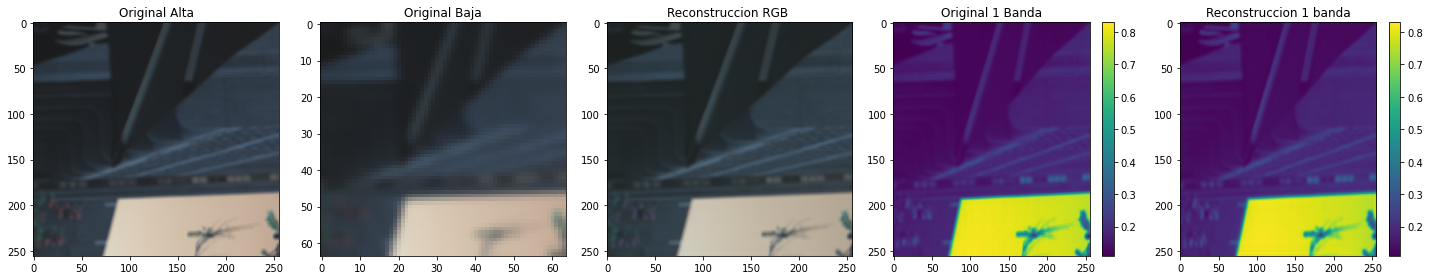

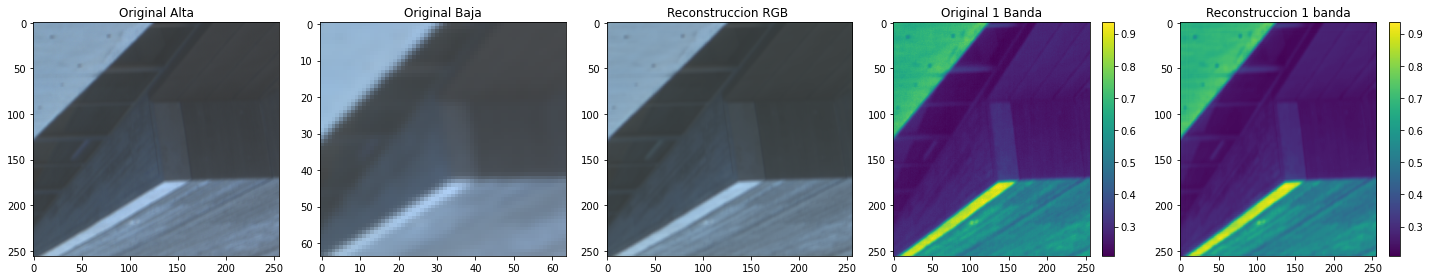

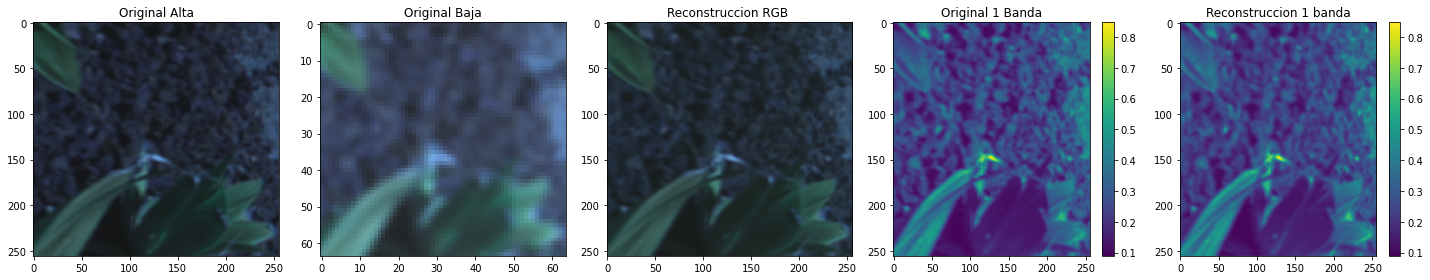

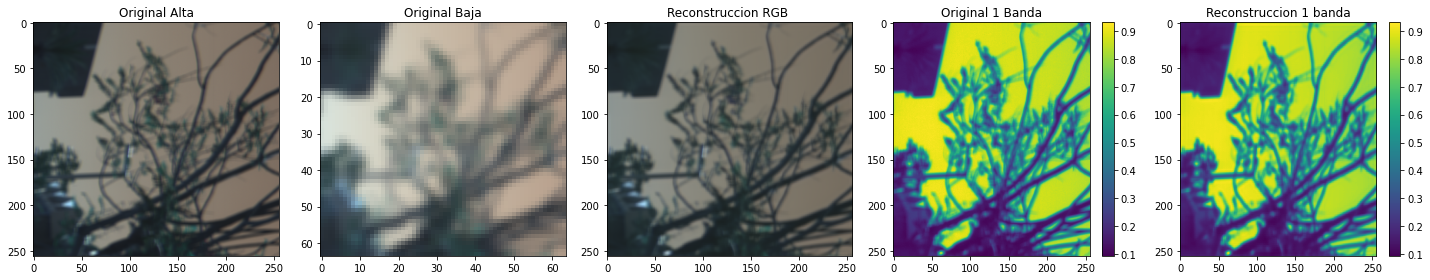

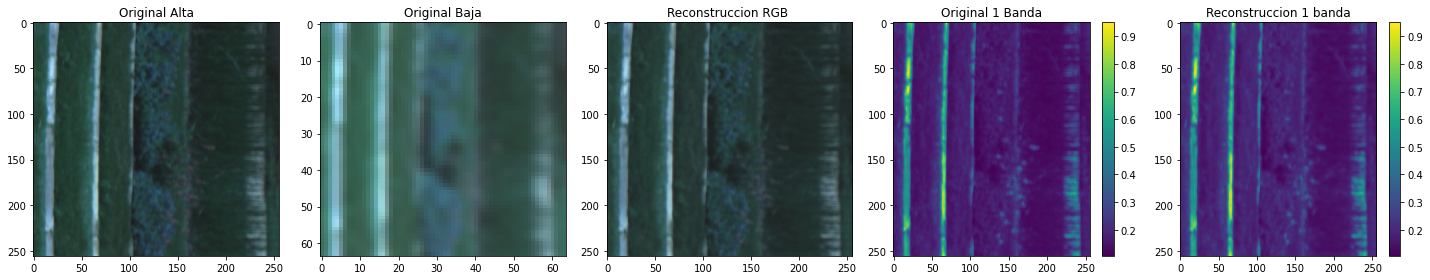

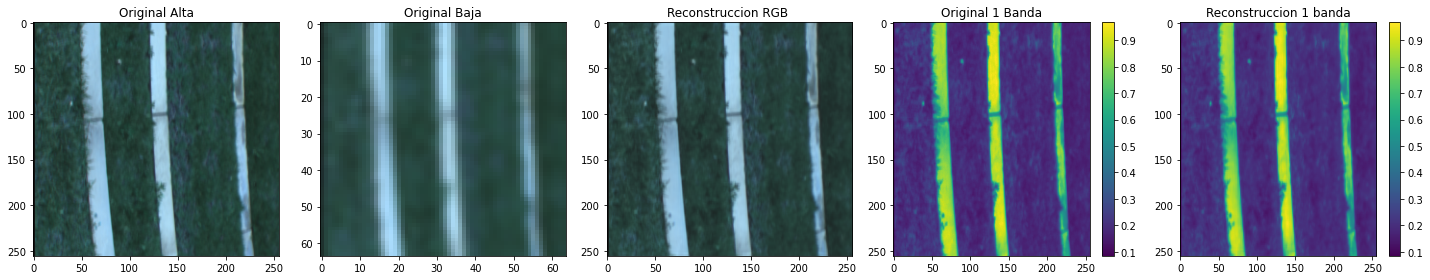

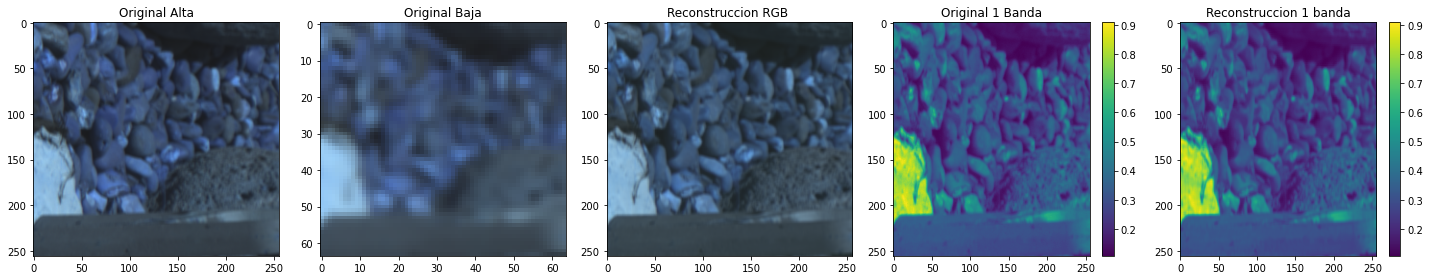

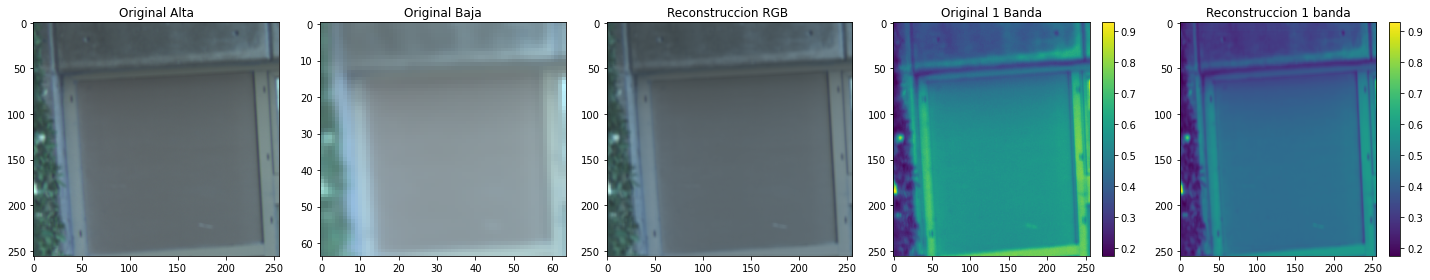

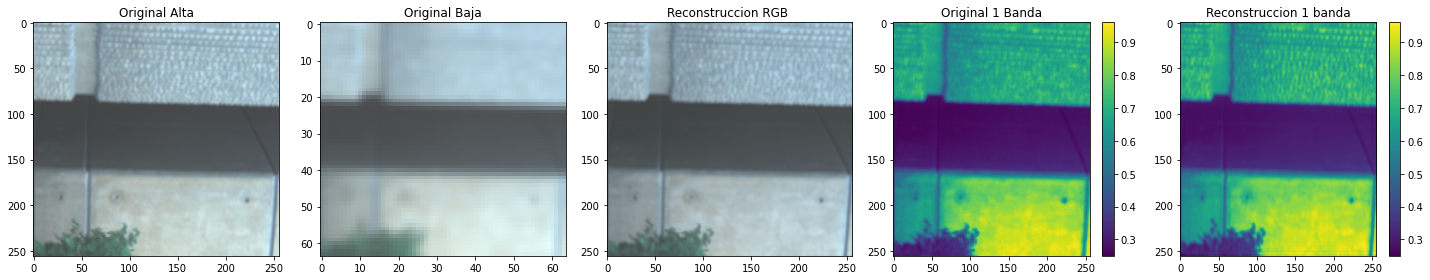

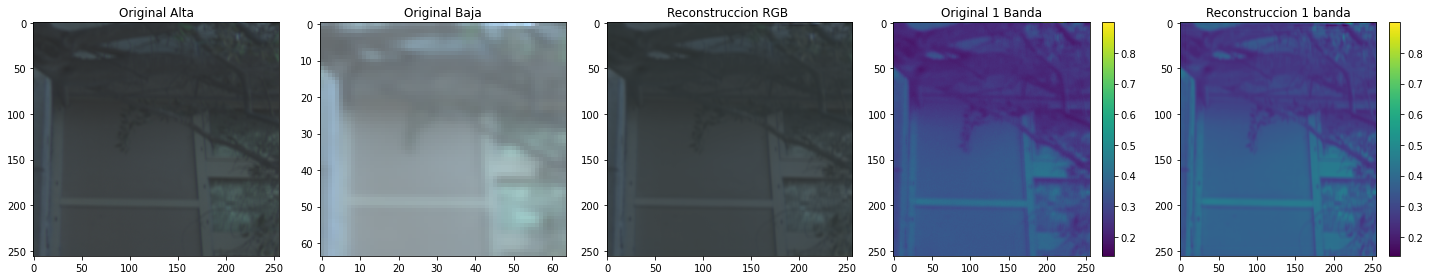

In [8]:
 ## Test

BATCH_SIZE = 10; EPOCHS=100; IMG_WIDTH = 256; IMG_HEIGHT = 256; L_bands = 12; 

# directory
dataset_path = '/content/drive/My Drive/High quality image test '
dataset_path_2 = '/content/drive/My Drive/Low quality image test '

dataset_dict = 'HI'
dataset_dict_2 = 'LI'

callback_path_gen = "/content/drive/My Drive/Loss/cp-{epoch:04d}.ckpt"
callback_dir_gen = os.path.dirname(callback_path_gen)
latest_gen = tf.train.latest_checkpoint(callback_dir_gen)

G = generator(pretrained_weights=latest_gen, input_size=(256, 256, 12), depth=12)

#---------------------Generador-----------------------------------------------------------------------------------------

D = ImageDataGenerator(horizontal_flip=True, vertical_flip=True)

params = {'dim': (IMG_WIDTH, IMG_HEIGHT, L_bands),
          'dim2': (64, 64, 12),
          'batch_size': BATCH_SIZE,
          'im_path': dataset_path,
          'im_path2':dataset_path_2,
          'dic_img': dataset_dict,
          'dic_img2': dataset_dict_2,
          'shuffle': True,
          'augment': False}  

HyperFiles = [
        fn  
        for fn in listdir(dataset_path)
        if isfile(join(dataset_path, fn))
           and fn.lower().endswith(('.mat'))
    ]

HyperFiles = HyperFiles[:300]
print('Training images: ',len(HyperFiles))

flag_tr=False
train_gen = DataGenerator(HyperFiles, flag_tr, D, **params)

x, y = train_gen.__getitem__(1)

generated_images = G(x)

for i in range(BATCH_SIZE):

  #Ploteamos Imagenes
  fig, axs = plt.subplots(figsize=(20, 4), ncols=5)
  fig.subplots_adjust(hspace=3)
  fig1 = axs[0].imshow(x[i,:,:,2:11:3], aspect='auto')  
  axs[0].set_title('Original Alta')

  fig2 = axs[1].imshow(y[i,:,:,2:11:3], aspect='auto')  
  axs[1].set_title('Original Baja')


  fig3 = axs[2].imshow(generated_images[i,:,:,2:11:3], aspect='auto')
  axs[2].set_title('Reconstruccion RGB ')
 

  fig4 = axs[3].imshow(x[i,:,:,1], aspect='auto')
  axs[3].set_title('Original 1 Banda')
  fig.colorbar(fig3, ax=axs[3])
  fig.tight_layout()

  fig5 = axs[4].imshow(generated_images[i,:,:,1], aspect='auto')
  axs[4].set_title('Reconstruccion 1 banda')
  fig.colorbar(fig3, ax=axs[4])
  fig.tight_layout()

value_PSNR = PSNR(x, generated_images)
print(value_PSNR)
print('Mean PSNR:', tf.reduce_mean(value_PSNR))
print(generated_images[i,1,1,:])
print(generated_images[i,1,1,1:16:4])
# Banda 1- 400 Banda 2- 430 Banda 3- 460 Banda 4- 480 Banda 5- 500  Banda 6- 530 - banda 7 560 